The following code is for the graphs in the paper. Majority of the work is done by the __init__ in the LotkaVolterraModel class. 

In [27]:
# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint,dblquad
import matplotlib.gridspec as gridspec
from math import sqrt
import logging 
from tabulate import tabulate

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
plt.rcParams["text.latex.preamble"] += r"\usepackage{amssymb}"

The all encompassing class structure for the general model. It plots the ode and the sde model. NOTE: T1 -  Evasive Tumor, T2- Baseline Tumor, B,dWt - Brownian motion

In [28]:
class LotkaVolterraModel:
    # Just initialing does everything but ode_details. This is because I wanted to generate the plots and tables in one go. If you want to just generate the table, you can just call the method after initializing the class with plot = False
    def __init__(self, r, gamma, alpha, beta, a, b, delta, p,q, K, nu,xi, sigma, R_0, S_0, I_0, C_0 , inital_proportion_a_n, initial_e_b, T, steps ,cstar, plot):
        self.r = r
        self.gamma = gamma
        self.alpha = alpha
        self.beta = beta
        self.a = a
        self.b = b
        self.delta = delta
        self.K = K
        self.nu = nu
        self.sigma = sigma
        self.initial_conditions = [R_0, S_0, I_0]
        self.dt = T/steps
        self.p = p
        self.q = q
        self.xi = xi 
        self.starsigma = sigma / sqrt(cstar)  # scaled sigma for the SDE compartments
        # Time points on which all the compartments are solved in
        self.T = T
        self.t = np.linspace(0, T, steps)
        self.N = len(self.t)
        self.cstar = cstar
        
        self.inital_proportion_a_n = inital_proportion_a_n
        self.initial_e_b = initial_e_b
        self.apoptotic_start , self.necrotic_start = (C_0 * self.inital_proportion_a_n)/self.cstar, (C_0 * (1-self.inital_proportion_a_n))/self.cstar
        self.evasive_start , self.baseline_start = (C_0 * self.initial_e_b)/self.cstar, (C_0 * (1-self.initial_e_b))/self.cstar
        
        
        # Solves the General Lotka-Volterra model and adds the results in the class variables
        self.solve(self.t)
        
        '''
        The Following code then generates all the paths using different assumptions for the noise and functional 
        form of the drift. The lists are then fed to a plot method to generate the pretty plots
        '''
        
        # Solve the Necrosis and Apoptosis Ct-DNA compartments using IID noise numerically
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N) # Generates a matrix with brownian steps)
        necrosis_num = self.solve_compartment(self.necrosis_f,  self.nu, self.necrotic_start, dWt) # Uses the newly generated dWt to solve the sde numerically
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N) # Generates a new independent matrix with brownian steps)
        apoptosis_num = self.solve_compartment(self.apoptosis_f,  self.nu, self.apoptotic_start, dWt) # Uses the newly generated dWt to solve the sde numerically

        # Solve the Baseline and Evasive Ct-DNA compartments using IID noise numerically
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N)
        evasive_num = self.solve_compartment(self.Ct_DNA_Evasive, self.nu, self.evasive_start, dWt)
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N)
        baseline_num = self.solve_compartment( self.Ct_DNA_Baseline, self.nu, self.baseline_start, dWt)

        # Solve the Evasive release mechs under same noise
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N) # Generates a matrix with brownian steps)
        necrosis_evasive_num = self.solve_compartment(self.Ct_DNA_evasive_necrosis, self.nu, self.necrotic_start * self.initial_e_b, dWt) # Uses the same dWt to solve the sde numerically
        apoptosis_evasive_num = self.solve_compartment( self.Ct_DNA_evasive_apoptosis, self.nu, self.apoptotic_start * self.initial_e_b , dWt)        

        # Solve the Baseline release mechs under same noise
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N)
        necrosis_baseline_num = self.solve_compartment(self.Ct_DNA_baseline_necrosis, self.nu, self.necrotic_start*(1-self.initial_e_b), dWt)
        apoptosis_baseline_num = self.solve_compartment( self.Ct_DNA_baseline_apoptosis, self.nu, self.apoptotic_start*(1-self.initial_e_b), dWt)        

        '''Path Solution for Baseline and Evasive Ct-DNA compartments. This one requires the full trajectory rather than just rates change. As such
        I made a method called simulate_brownian motion for this. 
        '''
        # Monte Carlo Simulation of the path solution using different noise
        self.W = self._simulate_brownian_motion() # Generates full trajectory and saves it as a class variable
        evasive_path =  self._simulate_paths( self.Ct_DNA_Evasive, self.evasive_start ) # Generates path solution using the analytical formula vis Euler Maruyama
        self.W = self._simulate_brownian_motion()
        baseline_path =  self._simulate_paths( self.Ct_DNA_Baseline ,self.baseline_start)

        # Path Solution for Baseline and Evasive Ct-DNA compartments using different noise
        self.W = self._simulate_brownian_motion()
        necrosis_path =  self._simulate_paths( self.necrosis_f,self.necrotic_start )
        self.W = self._simulate_brownian_motion()
        apoptosis_path =  self._simulate_paths( self.apoptosis_f ,self.apoptotic_start)

        # Path Solution for evasive compartments with same noise
        self.W = self._simulate_brownian_motion()
        necrosis_evasive_path =  self._simulate_paths( self.Ct_DNA_evasive_necrosis,self.necrotic_start * self.initial_e_b )
        apoptosis_evasive_path =  self._simulate_paths( self.Ct_DNA_evasive_apoptosis ,self.apoptotic_start * self.initial_e_b)
        
        # Path Solution for baseline compartments with same noise
        self.W = self._simulate_brownian_motion()
        necrosis_baseline_path =  self._simulate_paths( self.Ct_DNA_baseline_necrosis,self.necrotic_start*(1-self.initial_e_b) )
        apoptosis_baseline_path =  self._simulate_paths( self.Ct_DNA_baseline_apoptosis ,self.apoptotic_start*(1-self.initial_e_b))
        
                # Necrosis / Apoptosis
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N)
        necrosis_num_sqrt  = self.solve_compartment_sqrt(self.necrosis_f,  self.nu, self.necrotic_start, dWt)

        dWt = np.random.normal(0, np.sqrt(self.dt), self.N)
        apoptosis_num_sqrt = self.solve_compartment_sqrt(self.apoptosis_f, self.nu, self.apoptotic_start, dWt)

        # Baseline / Evasive
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N)
        evasive_num_sqrt   = self.solve_compartment_sqrt(self.Ct_DNA_Evasive,  self.nu, self.evasive_start, dWt)

        dWt = np.random.normal(0, np.sqrt(self.dt), self.N)
        baseline_num_sqrt  = self.solve_compartment_sqrt(self.Ct_DNA_Baseline, self.nu, self.baseline_start, dWt)

        # Mean and Variance of the solution for different drift f. Currently evasive and baseline
        mean_path_evasive= np.array([self.Mean_SDE_compartment(t,self.Ct_DNA_Evasive,self.evasive_start) for t in self.t])
        var_path_evasive = np.array([self.Var_SDE_compartment(t,self.Ct_DNA_Evasive, mean_path_evasive,self.evasive_start) for t in self.t])
        mean_path_baseline= np.array([self.Mean_SDE_compartment(t,self.Ct_DNA_Baseline,self.baseline_start) for t in self.t])
        var_path_baseline = np.array([self.Var_SDE_compartment(t,self.Ct_DNA_Baseline, mean_path_baseline,self.baseline_start) for t in self.t])
        
        # Mean and Variance of the solution for different drift f. Currently evasive and baseline
        mean_path_evasive_sqrt= np.array([self.Mean_SDE_compartment(t,self.Ct_DNA_Evasive,self.evasive_start,hat=True) for t in self.t])
        mean_path_baseline_sqrt= np.array([self.Mean_SDE_compartment(t,self.Ct_DNA_Baseline,self.baseline_start,hat=True) for t in self.t])

        var_path_evasive_sqrt = np.array([self.Var_SDE_hatf(t,self.Ct_DNA_Evasive, mean_path_evasive_sqrt,self.evasive_start) for t in self.t])
        var_path_baseline_sqrt = np.array([self.Var_SDE_hatf(t,self.Ct_DNA_Baseline, mean_path_baseline_sqrt,self.baseline_start) for t in self.t])
        
        # Plotting is based on order
        if plot:
            logging.info("plotting")    
            self.plot_paper(self.t, necrosis_num, apoptosis_num,
                            evasive_num, baseline_num,
                            evasive_path, baseline_path,
                            necrosis_path,apoptosis_path,
                            mean_path_evasive,var_path_evasive,
                            necrosis_evasive_num, apoptosis_evasive_num,
                            necrosis_baseline_num,apoptosis_baseline_num,
                            necrosis_evasive_path,apoptosis_evasive_path,
                            necrosis_baseline_path,apoptosis_baseline_path,
                            mean_path_baseline, var_path_baseline,
                            necrosis_num_sqrt,apoptosis_num_sqrt,
                            evasive_num_sqrt,baseline_num_sqrt,
                            mean_path_evasive_sqrt,mean_path_baseline_sqrt,
                            var_path_evasive_sqrt,var_path_baseline_sqrt
                            )

    def model(self, y, t):
        ''' 
        The general model - T1 Evasive, T2 Baseline, I Immune
        '''
        T1, T2, I = y
        dT1_dt = self.r * T1 * (1 - (T1 + self.p * T2) / self.K) - self.alpha * T1 * I
        dT2_dt = self.gamma * T2 * (1 - (self.q * T1 + T2) / self.K) - self.beta * T2 * I
        dI_dt = (self.a * T1 + self.b * T2  - self.delta) * (I)
        return [dT1_dt, dT2_dt, dI_dt]

    def solve(self, t):
        '''
        solving model using odint. Solution is stored as a class variable
        '''
        solution = odeint(self.model, self.initial_conditions, t)
        self.T1, self.T2, self.I = solution.T
    
    '''
    functions for different release mechanisms: In terms of the table, the first four represent the four entries and the last
    five represent the linear combination of interest for us
    '''
    def Ct_DNA_evasive_apoptosis(self, t):
        return (self.alpha * self.T1[t] * self.I[t])/ self.cstar
        
    def Ct_DNA_evasive_necrosis(self, t):
        return (self.r * self.T1[t]  * ( (self.T1[t] + self.p * self.T2[t]) / self.K))/ self.cstar
    
    def Ct_DNA_baseline_apoptosis(self, t):
        return  (self.beta * self.T2[t] * self.I[t] )/ self.cstar
    
    def Ct_DNA_baseline_necrosis(self, t):
        return (self.gamma * self.T2[t]* (  (self.q * self.T1[t] + self.T2[t]) / self.K))/ self.cstar
      
    def Ct_DNA_Evasive(self, t):
        return  self.Ct_DNA_evasive_apoptosis(t) + self.Ct_DNA_evasive_necrosis(t) 

    def Ct_DNA_Baseline(self, t):
        return  self.Ct_DNA_baseline_apoptosis(t) + self.Ct_DNA_baseline_necrosis(t) 

    def apoptosis_f(self, t):
        return self.Ct_DNA_evasive_apoptosis(t) + self.Ct_DNA_baseline_apoptosis(t)

    def necrosis_f(self, t):
        return  self.Ct_DNA_evasive_necrosis(t) + self.Ct_DNA_baseline_necrosis(t) 

    def all_compartments(self,t):
        return self.Ct_DNA_evasive_apoptosis(t) + self.Ct_DNA_baseline_apoptosis(t) + self.Ct_DNA_evasive_necrosis(t) + self.Ct_DNA_baseline_necrosis(t) 


    def solve_compartment(self, compartment_f,nu, initial,dWt):
        '''
        Euler-Marutama Scheme. takes in dWt
        '''
        C = np.zeros(self.N)
        C[0] = initial
        for i in range(1, self.N):
            C[i] = C[i-1] + (compartment_f(i-1) - nu * C[i-1]) * self.dt + self.sigma * C[i-1] * dWt[i-1]
        return C
    
    def _simulate_brownian_motion(self):
        '''
        Generates one trajectory for brownian motion. We do the same thing as generate dW here. In addition, we cumsum them
        to get the array for the brownian path. 
        '''
        dW = np.random.normal(0, np.sqrt(self.dt), self.N - 1)
        W = np.cumsum(dW)
        W = np.insert(W, 0, 0)  # Insert W(0) = 0
        return W
    
    def solve_compartment_sqrt(self, compartment_f, nu, initial, dWt):
        """
        Full-truncation Euler for: dC = ( (f(i) + xi) - nu*C ) dt + sigma*sqrt(C) dW
        where compartment_f(i) is index-based (i = 0,1,...).
        
        Full truncation:
        - drift uses max(C,0)
        - diffusion uses sqrt(max(C,0))
        This keeps the scheme stable and avoids sqrt of negative values.
        """
        C = np.zeros(self.N, dtype=float)
        C[0] = max(float(initial), 0.0)

        for i in range(1, self.N):
            C_prev = C[i-1]
            C_pos = max(C_prev, 0.0)

            fhat = compartment_f(i-1) + self.xi 
            drift = (fhat - nu * C_pos) * self.dt
            diff  = self.starsigma * np.sqrt(C_pos) * dWt[i-1]

            C[i] = C_prev + drift + diff

            # optional hard floor (often not needed with full truncation, but safe):
            if C[i] < 0.0:
                C[i] = 0.0

        return C

    def _simulate_paths(self, compartment_f,initial):
        '''
        Monte Carlo Simulation of the Analytical solution. 
        '''
        C0 = initial
        C = np.zeros(self.N)
        for i in range(self.N):
            # Exponential term
            C[i] = C0 * np.exp(self.sigma * self.W[i] - (self.nu + 0.5 * self.sigma**2) * self.t[i])
            
            # Integral term
            integral_term = 0
            for s in range(i):
                integral_term += np.exp(self.sigma * (self.W[i] - self.W[s]) - (self.nu + 0.5 * self.sigma**2) * (self.t[i] - self.t[s])) *  compartment_f(s) * self.dt
                
            C[i] += integral_term
        return C
    
    def ode_details(self):
        '''     
        This generates the table of values of all equilibrium points given the analytical findings of the model. Our paper has strict inequality
        assumptions so there might be cases where we have missed with the stability analysis.
        '''
        def exists(eqpoints):
            logic = []
            for i, eq in enumerate(eqpoints):
                x,y,z = eq
                if i <= 2:
                    logic.append(True) 
                if i == 3:
                    logic.append(all([0 < y < self.K, 0 < z ]))
                if i == 4:
                    logic.append(all([0 < x < self.K, 0 < z ]))
                if i == 5:
                    logic.append(all([0 < x < self.K, 0 < y < self.K ]))
                if i == 6:
                    logic.append(all([0 < x < self.K, 0 < y < self.K , 0 < z]))
            return logic
        
        def stability(eqpoints):
            logic_list = []
            for i, eq in enumerate(eqpoints):
                x,y,z = eq
                if i == 0:   
                    logic_list.append(False)
                if i == 1:
                    if self.K < self.delta/self.b and self.p > 1:
                        truth = True
                    else:
                        truth = False    
                    logic_list.append(truth)  
                if i == 2:
                    if self.K < self.delta/self.a and self.q > 1:
                        truth = True
                    else:
                        truth = False    
                    logic_list.append(truth)
                if i == 3:
                    if self.K > self.delta/self.b and self.p > 1 + (1 - (self.gamma * self.alpha) /( (self.r * self.beta)  ) )* (((self.b*self.K)/ self.delta)-1):
                        truth = True
                    else:
                        truth = False    
                    logic_list.append(truth)
                if i == 4:
                    if self.K > self.delta/self.a and self.q > 1 + (1 - ( (self.r * self.beta) / (self.gamma * self.alpha) ) )* (((self.a * self.K)/ self.delta)-1):
                        truth = True
                    else:
                        truth = False    
                    logic_list.append(truth) 
                if i == 5:
                    if self.p < 1 and self.q < 1 and self.delta > self.K * (self.a*(1-self.p) +self.b*(1-self.q) ) / (1 - self.p * self.q):
                        truth = True
                    else:
                        truth = False    
                    logic_list.append(truth)
                if i == 6:
                    psi = self.gamma * self.alpha * self.q - self.r * self.beta
                    phi = self.gamma * self.alpha - self.beta * self.r * self.p
                    theta = (self.gamma * self.alpha - self.beta * self.r ) *self.K
                    
                    T1 = (self.delta* phi - theta * self.b) / (phi * self.a - psi * self.b)
                    T2 = (self.a * theta  - self.delta * psi) / (phi * self.a - psi * self.b)
                    A = self.compute_A(T1,T2)
                    B = self.compute_B(T1,T2)
                    C = self.compute_C(T1,T2)
                    if all([A>0, C >0 , A*B -C > 0]):
                        truth = True
                    else:
                        truth = False     
                    logic_list.append(truth)
            return logic_list
        
        # params needed for stability for interior state
        psi = self.gamma * self.alpha * self.q - self.r * self.beta
        phi = self.gamma * self.alpha - self.beta * self.r * self.p
        theta = (self.gamma * self.alpha - self.beta * self.r ) *self.K
        
        # Interior Equilibrium point based on the parameters chosen
        T1 = (self.delta* phi - theta * self.b) / (phi * self.a - psi * self.b)
        T2 = (self.a * theta  - self.delta * psi) / (phi * self.a - psi * self.b)
        I  =( (self.r / (self.alpha * self.K)) *( self.K - T1 - self.p*T2) + (self.gamma / (self.beta * self.K)) *(self.K - self.q* T1 - T2)) / 2
        
        eqpoints = [(0,0,0),\
                    (0,self.K,0),\
                    (self.K,0,0), \
                    ( 0 ,self.delta/self.b, (self.gamma/self.beta) *(1 - (self.delta)/(self.b*self.K))),\
                    (self.delta / self.a, 0 , (self.r / self.alpha)*(1 - (self.delta)/(self.a*self.K))),\
                    (self.K * ( 1  - self.p )/ (1-self.p * self.q)  ,   self.K * ( 1  - self.q )/ (1-self.p * self.q) ,0   ),\
                    (T1,T2,I)]
        # Note that both exists and stability are position dependent. If you change order in the list above, you have
        # to change the order in the exits and stability methods    
        existence = exists(eqpoints)
        stability = stability(eqpoints)
        def format_tuple(tup):
            return tuple(f'{pt:.1f}' for pt in tup)

        def format_existance(exists):
            return "Exists" if exists else "Does not exist"

        def format_stability(stable, exists):
            if not exists:
                return "Does not exist"
            return "Stable" if stable else "Unstable"

        formatted_eqpoints = [format_tuple(pt) for pt in eqpoints]
        formatted_existance = [format_existance(ex) for ex in existence]
        formatted_stability = [format_stability(stab, ex) for stab, ex in zip(stability, existence)]

        data = {'Eqpoints': eqpoints, 'Existance': formatted_existance, 'Stability': formatted_stability}
        df = pd.DataFrame(data)
        print(tabulate(df, headers='keys', tablefmt='grid', showindex=False))
        
        # Function to apply conditional formatting
        def highlight_stable_and_exists(row):
            # If both existance and stability are "exists", apply a green background
            if row['Existance'] == "Exists" and row['Stability'] == "Stable":
                return ['background-color: lightgreen'] * len(row)
            else:
                return [''] * len(row)

        # Apply conditional formatting to the DataFrame
        styled_df = df.style.apply(highlight_stable_and_exists, axis=1)
        return styled_df
        
    '''  
    compute_A, compute_B, compute_C come from the SI and is needed for stability of the interior state
    '''    
    
    def compute_A(self, T1, T2):
        return (self.r * T1 / self.K) + (self.gamma * T2 / self.K) - (self.a * T1) - (self.b * T2) + self.delta

    def compute_B(self, T1, T2):
        B = (self.r * self.gamma * T1 * T2 / self.K**2) -(self.r * self.a * T1**2 / self.K) - (self.r * self.b * T1 * T2 / self.K) \
            + (self.r * self.delta * T1 / self.K) - (self.gamma * self.a * T1 * T2 / self.K) - (self.gamma * self.b * T2**2 / self.K) \
            + (self.gamma * T2 * self.delta / self.K) + (self.b * self.gamma * T2) - (self.b * self.gamma * self.q * T1 * T2 / self.K) \
            - (self.b * self.gamma * T2**2 / self.K) - (self.r * self.p * self.gamma * self.q *T1 * T2 / self.K**2) + (self.a* self.r* T1) \
            -(self.a * self.r * T1**2 / self.K ) - (self.a * self.r * self.p * T1 * T2 / self.K**2)
        return B

    def compute_C(self,T1,T2):
        term1 = (-(self.r * self.gamma * self.a * T1**2 * T2) / self.K**2 - (self.r * self.gamma * self.b * T1 * T2**2) / self.K**2
                 + (self.r * self.gamma * self.delta * T1 * T2) / self.K**2 + (self.r * self.b * self.gamma * T1 * T2) / self.K
                 - (self.r * self.b * self.gamma * self.q * T1**2 * T2) / self.K**2 -  (self.r * self.b * self.gamma * T1 * T2**2) / self.K**2)
                 
        term2 = (( self.r * self.p * self.gamma * self.q * self.a * T1**2 * T2) / self.K**2 + (self.r * self.p * self.gamma * self.q * self.b * T1 * T2**2) / self.K**2
                 - (self.r * self.p * self.gamma * self.q * self.delta * T1 * T2) / self.K**2 - (self.a * self.beta * self.r**2 * self.p * T1 * T2) / (self.alpha * self.K)
                 + (self.a * self.beta * self.r**2 * self.p * T1**2 * T2) / (self.alpha * self.K**2) + (self.a * self.beta * self.r**2 * self.p**2 * T1 * T2**2) / (self.alpha * self.K**2))
                 
        term3 = -(self.alpha * T1 * ((self.b * self.gamma**2 * self.q * T2) / (self.beta * self.K) - (self.b * self.gamma**2 * self.q**2 * T1 * T2) / (self.beta * self.K**2)
                 - (self.b * self.gamma**2 * self.q * T2**2) / (self.beta * self.K**2) - (self.a * self.gamma * self.r * T2) / (self.alpha * self.K)
                 + (self.a * self.gamma * self.r * T1 * T2) / (self.alpha * self.K**2) + (self.a * self.gamma * self.r * self.p * T2**2) / (self.alpha * self.K**2)))         
        C = term1 + term2 + term3
        return C
    
    def Mean_SDE_compartment(self, t, compartment_f,start_c0,hat = False):
        '''
        Generates the Mean trajectory using the analytical formula
        using different compartment entries
        I use the trapezium rule to generate the integrals 
        '''
        # Find the indices in t_values where s <= t
        indices = np.where(self.t <= t)[0]
        # Extract corresponding s values and f(s) values
        s_values = self.t[indices]
        if hat == False:
            f_values = np.array([compartment_f(s) for s in indices])
        else:
            f_values = np.array([compartment_f(s)  for s in indices]) + self.xi

        # Calculate the integrand e^{-\eta (t - s)}
        integrand = f_values * np.exp(- self.nu * (t - s_values))
        
        # Use the trapezoidal rule for numerical integration
        integral = np.trapezoid(integrand, s_values)
        
        # Return the value of m(t)
        return (start_c0 * np.exp(-self.nu * t)) + integral
    
    def Var_SDE_compartment(self,t, compartment_f, compartment_mean,start_c0):
        '''
        Generates the Variance trajectory using the analytical formula
        using different compartment entries
        I use the trapezium rule to generate the integrals 
        '''
        
        term1 = start_c0**2 * np.exp((self.sigma**2 - 2 * self.nu) * t)
        term3 = pow(self.Mean_SDE_compartment(t, compartment_f,start_c0),2)
        
        indices = np.where(self.t <= t)[0]
        s_values = self.t[indices]
        
        f_values = np.array([compartment_f(idx) for idx in indices])
        m_values = np.array([compartment_mean[idx] for idx in indices])
        
        integrand = 2 * np.exp((self.sigma**2 - 2 * self.nu) * (t - s_values)) * m_values * f_values
        
        integral = np.trapezoid(integrand, s_values)    
        
        variance = term1 - term3 + integral
        return variance
    
    def Var_SDE_hatf(self, t, compartment_f, compartment_mean, start_c0):
        """
        Generates the Variance trajectory using the analytical formula for the SDE with hatf drift, which can be negative.
        This is based on the formula derived in the Appendix, and uses the trapezoidal rule for numerical integration.
        """
        indices = np.where(self.t <= t)[0]
        s_values = self.t[indices]              
        i = indices[-1]                          

        m_values = np.array([compartment_mean[idx] for idx in indices], dtype=float)
        m_t = compartment_mean[i]

        fhat_values = np.array([compartment_f(idx) for idx in indices], dtype=float) + self.xi

        term1 = (start_c0 ** 2) * np.exp(-2.0 * self.nu * t)

        integrand = (2.0 * fhat_values + self.starsigma **2) * np.exp(-2.0 * self.nu * (t - s_values)) * m_values
        integral = np.trapezoid(integrand, s_values)

        variance = term1 + integral - (m_t ** 2)
        return variance
    
    def Var_SDE_hatf_stable(self, t, compartment_mean, start_c0):
        """
        Generates the Variance trajectory using the analytical formula for the stable SDE with hatf drift, 
        which is guaranteed to be non-negative. This is based on the formula derived in the Appendix, and uses the trapezoidal rule for numerical integration.
        """
        indices = np.where(self.t <= t)[0]
        s_values = self.t[indices]
        m_values = np.array([compartment_mean[idx] for idx in indices], dtype=float)


        integrand = (self.starsigma**2) * np.exp(-2.0 * self.nu * (t - s_values)) * m_values
        V = np.trapezoid(integrand, s_values)  # since V(0)=0
        return V
    
    def Mean_return_compartment(self, eqstate):
        '''
        Generates the Mean time to return trajectory using the analytical formula
        given equilibrium state
        I use the trapezium rule to generate the integrals 
        '''
        
        evasive_apoptosis = lambda E,B,I :  (self.alpha * E * I)/ self.cstar
        evasive_necrosis = lambda E,B,I :(self.r * E  * ( (E + self.p * B) / self.K))/ self.cstar
        baseline_apoptosis  = lambda E,B,I :  (self.beta * B * I )/ self.cstar
        baseline_necrosis  = lambda E,B,I :(self.gamma * B* (  (self.q * E + B) / self.K))/ self.cstar
        fstar = evasive_apoptosis(*eqstate) + evasive_necrosis(*eqstate) + baseline_apoptosis(*eqstate) + baseline_necrosis(*eqstate)
        
        p = lambda x : 2*( fstar - self.nu *x) / (pow(self.sigma * x,2))
        q = lambda x : (-2) / (pow(self.sigma * x,2))
        
        def inner_integral(v, y):
            return np.exp(-np.trapezoid([p(z) for z in np.linspace(v, y, 100)], np.linspace(v, y, 100)))

        def integrand(v, y, x0):
            return inner_integral(v, y) * q(v)
        
        epsilon = 1e-5
        range_for_x = np.linspace(0.2, 1 , 100)
        return_time_start = {}
        for x0 in range_for_x:
            # Perform the double integral
            result, error = dblquad(lambda y, v: integrand(v, y, x0), x0, 1, lambda v: x0, lambda v: v)

            final_result = -result
            return_time_start[x0]= final_result
            
        return return_time_start, fstar
   
    def plot_paper(self, t, necrosis_num, apoptosis_num,
                           evasive_num, baseline_num,
                           evasive_path, baseline_path,
                           necrosis_path,apoptosis_path,
                           mean_path_evasive,var_path_evasive,
                           necrosis_evasive_num, apoptosis_evasive_num,
                           necrosis_baseline_num,apoptosis_baseline_num,
                           necrosis_evasive_path,apoptosis_evasive_path,
                           necrosis_baseline_path,apoptosis_baseline_path,
                           mean_path_baseline, var_path_baseline,
                           necrosis_num_sqrt,apoptosis_num_sqrt,
                           evasive_num_sqrt,baseline_num_sqrt, 
                           mean_path_evasive_sqrt,mean_path_baseline_sqrt,
                           var_path_evasive_sqrt,var_path_baseline_sqrt ):
        
        '''
        Plots to use for the paper
        '''
        
        plt.figure(figsize=(10, 4))
        plt.plot(t, self.T1, label='Evasive Tumor ($E$)')
        plt.plot(t, self.T2, label='Baseline Tumor ($B$)')
        plt.plot(t, self.I, label='Immune ($I$)')
        plt.xlabel('Time')
        plt.ylabel('Population')
        plt.title('Lotka-Volterra Model with One Immune and Two Tumor Sub-Clones \n' f'r = {self.r}, gamma = {self.gamma}, alpha = {self.alpha}, beta = {self.beta}, a = {self.a}, b = {self.b}, \n' f'delta = {self.delta}, p = {self.p} , q = {self.q}, K = {self.K}, nu = {self.nu}, sigma= {self.sigma}, \n' f'($E_0$, $B_0$, $I_0$)= ({self.initial_conditions[0]}, {self.initial_conditions[1]}, {self.initial_conditions[2]}), $C_0$ = {self.apoptotic_start + self.necrotic_start}, T = {self.T}, $C^*$ = {self.cstar}', fontsize=10)
        plt.legend()
        plt.show
        
        text_fontsize = 13
        fig = plt.figure(figsize=(20, 24))
        gs = gridspec.GridSpec(4, 2, height_ratios=[1, 1, 1, 1], width_ratios=[1, 1])

        ax1 = plt.subplot(gs[0, :])
        ax1.plot(t, self.T1, label='Evasive Tumor ($E$)')
        ax1.plot(t, self.T2, label='Baseline Tumor ($B$)')
        ax1.plot(t, self.I, label='Immune ($I$)')
        ax1.set_xlabel('Time',fontsize=text_fontsize)
        ax1.set_ylabel('Population',fontsize=text_fontsize)
        ax1.set_title('Lotka-Volterra Model with One Immune and Two Tumor Sub-Clones')
        ax1.legend()

        ax2 = plt.subplot(gs[1, 0])
        ax2.plot(t, evasive_num + baseline_num, label='SDE Numerical', linestyle='--', color='pink')
        ax2.plot(t, evasive_path + baseline_path, label='Path Solution',  color='red')
        ax2.plot(t, evasive_num_sqrt + baseline_num_sqrt, label='SDE Numerical (sqrt)', linestyle='--', color='purple')
        ax2.set_xlabel('Time',fontsize=text_fontsize)
        ax2.set_ylabel('Biomarker abundance',fontsize=text_fontsize)
        ax2.set_title('Cumulative Biomarker Diffusion (Path and Numerical)')       
        ax2.legend()

        ax3 = plt.subplot(gs[1, 1])
        ax3.plot(t, necrosis_path, label='Necrotic Biomarker abundance (Path)', color='red')
        ax3.plot(t, apoptosis_path, label='Apoptotic Biomarker abundance (Path)', color='blue')
        ax3.plot(t, necrosis_num, label='Necrotic Biomarker abundance (Numerical)', linestyle='--', color='pink')
        ax3.plot(t, apoptosis_num, label='Apoptotic Biomarker abundance (Numerical)', linestyle='--', color='skyblue')
        ax3.plot(t, necrosis_num_sqrt,
         label='Necrotic Biomarker (Num, sqrt)', linestyle='--', color='purple')
        ax3.plot(t, apoptosis_num_sqrt,
                label='Apoptotic Biomarker (Num, sqrt)', linestyle='--', color='orchid')

        ax3.set_xlabel('Time',fontsize=text_fontsize)
        ax3.set_ylabel('Biomarker abundance',fontsize=text_fontsize)
        ax3.set_title('Biomarker Diffusion (Path and Numerical Solution)')
        ax3.legend()
                               
        ax4 = plt.subplot(gs[2, 0])
        ax4.plot(t, evasive_path, label='Evasive Clone (Path)', color='red')
        ax4.plot(t, baseline_path, label='Baseline Clone (Path)', color='blue')
        ax4.plot(t, evasive_num, label='Evasive Clone (Num)', linestyle='--', color='pink')
        ax4.plot(t, baseline_num, label='Baseline Clone (Num)', linestyle='--', color='skyblue')
        ax4.plot(t, evasive_num_sqrt,
         label='Evasive Clone (Num, sqrt)', linestyle='--', color='purple')
        ax4.plot(t, baseline_num_sqrt,  
         label='Baseline Clone (Num, sqrt)', linestyle='--', color='orchid')
        ax4.set_xlabel('Time',fontsize=text_fontsize)
        ax4.set_ylabel('Biomarker Proportion wrt $C^*$',fontsize=text_fontsize)
        ax4.set_title('Biomarker Diffusion via Clonal Source(Path and Numerical)')
        ax4.legend()

        ax5 = plt.subplot(gs[2, 1])
        ax5.plot(t, necrosis_evasive_num, label='N Evasive (Num)', linestyle='--', color='pink')
        ax5.plot(t, apoptosis_evasive_num, label='A Evasive (Num)',linestyle='--', color='skyblue')
        ax5.plot(t, necrosis_baseline_num, label='N Baseline (Num)', linestyle='--', color='bisque')
        ax5.plot(t, apoptosis_baseline_num, label='A Baseline (Num)', linestyle='--', color='silver')
        
        ax5.plot(t, necrosis_evasive_path, label='N Evasive (Path)', color='red')
        ax5.plot(t, apoptosis_evasive_path, label='A Evasive (Path)', color='blue')
        ax5.plot(t, necrosis_baseline_path, label='N Baseline (Path)',  color= 'darkorange')
        ax5.plot(t, apoptosis_baseline_path, label='A Baseline (Path)', color='black')
        
        ax5.set_xlabel('Time',fontsize=text_fontsize)
        ax5.set_ylabel('Biomarker Proportion wrt $C^*$',fontsize=text_fontsize)
        ax5.set_title('Biomarker Diffusion via Mechanism Source ')
        ax5.legend()
        
        ax6 = plt.subplot(gs[3, 0])
        std_dev_evasive = np.sqrt(np.maximum(var_path_evasive, 0))
        upper_bound_evasive = mean_path_evasive + std_dev_evasive
        lower_bound_evasive = mean_path_evasive - std_dev_evasive

        std_dev_baseline = np.sqrt(np.maximum(var_path_baseline, 0))
        upper_bound_baseline = mean_path_baseline + std_dev_baseline
        lower_bound_baseline = mean_path_baseline - std_dev_baseline

        ax6.plot(t, mean_path_evasive, label='Evasive Mean', color='darkred')
        ax6.plot(t, mean_path_baseline, label='Baseline Mean', color='darkblue')

        ax6.fill_between(
            t, lower_bound_evasive, upper_bound_evasive,
            color='lightcoral', alpha=0.2, label='Evasive ± 1 Std-dev'
        )
        ax6.fill_between(
            t, lower_bound_baseline, upper_bound_baseline,
            color='lightskyblue', alpha=0.2, label='Baseline ± 1 Std-dev'
        )

        ax6.plot(t, evasive_num, '--', color='pink', label='Evasive (Num)')
        ax6.plot(t, evasive_path, color='red', label='Evasive (Path)')
        ax6.plot(t, baseline_num, '--', color='deepskyblue', label='Baseline (Num)')
        ax6.plot(t, baseline_path, color='dodgerblue', label='Baseline (Path)')

        ax6.set_title('Geometric Biomarker Diffusion with Mean and Variance Cone')
        ax6.set_xlabel('Time',fontsize=text_fontsize)
        ax6.set_ylabel('Biomarker Proportion',fontsize=text_fontsize)
        ax6.legend()
        ax6.grid(alpha=0.3)
        
        
        ax7 = plt.subplot(gs[3, 1])
        std_dev_evasive_sqrt = np.sqrt(np.maximum(var_path_evasive_sqrt, 0))
        upper_bound_evasive_sqrt = mean_path_evasive_sqrt + std_dev_evasive_sqrt
        lower_bound_evasive_sqrt = mean_path_evasive_sqrt - std_dev_evasive_sqrt

        std_dev_baseline_sqrt = np.sqrt(np.maximum(var_path_baseline_sqrt, 0))
        upper_bound_baseline_sqrt = mean_path_baseline_sqrt + std_dev_baseline_sqrt
        lower_bound_baseline_sqrt = mean_path_baseline_sqrt - std_dev_baseline_sqrt

        ax7.fill_between(
            t, lower_bound_evasive_sqrt, upper_bound_evasive_sqrt,
            color='lightcoral', alpha=0.2, label='Evasive ± 1 Std-dev'
        )
        ax7.fill_between(
            t, lower_bound_baseline_sqrt, upper_bound_baseline_sqrt,
            color='lightskyblue', alpha=0.2, label='Baseline ± 1 Std-dev'
        )

        ax7.plot(t, mean_path_evasive_sqrt, label='Evasive Mean', color='darkred')
        ax7.plot(t, mean_path_baseline_sqrt, label='Baseline Mean', color='darkblue')
        ax7.plot(t, evasive_num_sqrt, '--', color='pink', label='Evasive')
        ax7.plot(t, baseline_num_sqrt, '--', color='deepskyblue', label='Baseline')

        ax7.set_title('Square Root Biomarker Diffusion with Mean and Variance Cone')
        ax7.set_xlabel('Time',fontsize=text_fontsize)
        ax7.set_ylabel('Biomarker Proportion',fontsize=text_fontsize)
        ax7.legend()
        ax7.grid(alpha=0.3)
        
        
        fig.suptitle(f'r = {self.r}, gamma = {self.gamma}, alpha = {self.alpha}, beta = {self.beta}, a = {self.a}, b = {self.b}, delta = {self.delta}, p = {self.p} , q = {self.q}, K = {self.K}, nu = {self.nu}, sigma= {self.sigma}, ($E_0$, $B_0$, $I_0$)= ({self.initial_conditions[0]}, {self.initial_conditions[1]}, {self.initial_conditions[2]}), $C_0$ = {self.apoptotic_start}, T = {self.T}, $C^*$ = {self.cstar}')
        plt.tight_layout(rect=[0, 0, 1, 0.97])

        plt.show()
        
        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(10, 8), sharex=True
        )

        # ---------- Top plot  ----------

        std_dev_evasive = np.sqrt(np.maximum(var_path_evasive, 0))
        upper_bound_evasive = mean_path_evasive + std_dev_evasive
        lower_bound_evasive = mean_path_evasive - std_dev_evasive

        std_dev_baseline = np.sqrt(np.maximum(var_path_baseline, 0))
        upper_bound_baseline = mean_path_baseline + std_dev_baseline
        lower_bound_baseline = mean_path_baseline - std_dev_baseline

        ax1.plot(t, mean_path_evasive, label='Evasive Mean', color='darkred')
        ax1.plot(t, mean_path_baseline, label='Baseline Mean', color='darkblue')

        ax1.fill_between(
            t, lower_bound_evasive, upper_bound_evasive,
            color='lightcoral', alpha=0.2, label='Evasive ± 1 Std-dev'
        )
        ax1.fill_between(
            t, lower_bound_baseline, upper_bound_baseline,
            color='lightskyblue', alpha=0.2, label='Baseline ± 1 Std-dev'
        )

        ax1.plot(t, evasive_num, '--', color='pink', label='Evasive (Num)')
        ax1.plot(t, evasive_path, color='red', label='Evasive (Path)')
        ax1.plot(t, baseline_num, '--', color='deepskyblue', label='Baseline (Num)')
        ax1.plot(t, baseline_path, color='dodgerblue', label='Baseline (Path)')

        ax1.set_title('Geometric Ct-DNA Diffusion with\nMean and Variance Cone')
        ax1.legend()
        ax1.grid(alpha=0.3)

        # ---------- Bottom plot -------------
        std_dev_evasive_sqrt = np.sqrt(np.maximum(var_path_evasive_sqrt, 0))
        upper_bound_evasive_sqrt = mean_path_evasive_sqrt + std_dev_evasive_sqrt
        lower_bound_evasive_sqrt = mean_path_evasive_sqrt - std_dev_evasive_sqrt

        std_dev_baseline_sqrt = np.sqrt(np.maximum(var_path_baseline_sqrt, 0))
        upper_bound_baseline_sqrt = mean_path_baseline_sqrt + std_dev_baseline_sqrt
        lower_bound_baseline_sqrt = mean_path_baseline_sqrt - std_dev_baseline_sqrt
        
        ax2.fill_between(
            t, lower_bound_evasive_sqrt, upper_bound_evasive_sqrt,
            color='lightcoral', alpha=0.2, label='Evasive ± 1 Std-dev'
        )
        ax2.fill_between(
            t, lower_bound_baseline_sqrt, upper_bound_baseline_sqrt,
            color='lightskyblue', alpha=0.2, label='Baseline ± 1 Std-dev'
        )
        
        ax2.plot(t, mean_path_evasive_sqrt, label='Evasive Mean', color='darkred')
        ax2.plot(t, mean_path_baseline_sqrt, label='Baseline Mean', color='darkblue')
        ax2.plot(t, evasive_num_sqrt, '--', color='pink', label='Evasive')
        ax2.plot(t, baseline_num_sqrt, '--', color='deepskyblue', label='Baseline')

        ax2.set_xlabel('Time')
        ax2.set_ylabel('Ct-DNA Proportion')
        ax2.set_title('Square Root Ct-DNA Diffusion with \nMean and Variance Cone')
        ax2.legend()
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        
        # Figure with two subplots side by side
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # First plot on the left (Lotka-Volterra Model)
        ax1.plot(t, self.T1, label='Evasive Tumor ($E$)')
        ax1.plot(t, self.T2, label='Baseline Tumor ($B$)')
        ax1.plot(t, self.I, label='Immune ($I$)')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Population')
        ax1.set_title('Lotka-Volterra Model with One Immune and Two Tumor Sub-Clones')
        ax1.legend()

        # Second plot on the right (Necrosis and Apoptosis Path and Num)
        ax2.plot(t, necrosis_evasive_num + necrosis_baseline_num, label='Necrosis (Geo)', linestyle='--', color='pink')
        ax2.plot(t, apoptosis_evasive_num + apoptosis_baseline_num, label='Apoptosis (Geo)', linestyle='--', color='skyblue')
        
        ax2.plot(t, necrosis_num_sqrt, label='Necrosis (CIR)', color='red')
        ax2.plot(t, apoptosis_num_sqrt, label='Apoptosis (CIR)', color='black')

        ax2.set_xlabel('Time')
        ax2.set_ylabel('Ct-Dna Proportion')
        ax2.set_title('Necrosis and Apoptosis (Geometric vs CIR)')
        ax2.legend()


        plt.tight_layout()
        plt.show()
        
        ode_param_text = (
        r"$r=%.2f,\ \gamma=%.2f,\ \alpha=%.2f,\ \beta=%.2f,$ "
        r"$a=%.4f,\ b=%.2f,\ \delta=%.2f,$ "
        r"$p=%.2f,\ q=%.2f,\ K=%.0f;$ "
        r"$E_0=%.1f,\ B_0=%.1f,\ I_0=%.1f$"
        % (self.r, self.gamma, self.alpha, self.beta, self.a, self.b, self.delta, self.p, self.q, self.K, self.initial_conditions[0], self.initial_conditions[1], self.initial_conditions[2])
        )
        param_text_geo = (
        r"$\eta = %.3f,\ \sigma = %.3f$"
        % (self.nu, self.sigma)
        ) +  ode_param_text
        # ---------- Figure 1: Geometric Ct-DNA Diffusion ----------

        fig1, ax1 = plt.subplots(figsize=(10, 4))

        std_dev_evasive = np.sqrt(np.maximum(var_path_evasive, 0))
        upper_bound_evasive = mean_path_evasive + std_dev_evasive
        lower_bound_evasive = mean_path_evasive - std_dev_evasive

        std_dev_baseline = np.sqrt(np.maximum(var_path_baseline, 0))
        upper_bound_baseline = mean_path_baseline + std_dev_baseline
        lower_bound_baseline = mean_path_baseline - std_dev_baseline

        ax1.plot(t, mean_path_evasive, label='Evasive Mean', color='darkred')
        ax1.plot(t, mean_path_baseline, label='Baseline Mean', color='darkblue')

        ax1.fill_between(
            t, lower_bound_evasive, upper_bound_evasive,
            color='lightcoral', alpha=0.2, label='Evasive ± 1 Std-dev'
        )
        ax1.fill_between(
            t, lower_bound_baseline, upper_bound_baseline,
            color='lightskyblue', alpha=0.2, label='Baseline ± 1 Std-dev'
        )

        ax1.plot(t, evasive_num, '--', color='pink', label='Evasive (Num)')
        ax1.plot(t, evasive_path, color='red', label='Evasive (Path)')
        ax1.plot(t, baseline_num, '--', color='deepskyblue', label='Baseline (Num)')
        ax1.plot(t, baseline_path, color='dodgerblue', label='Baseline (Path)')

        ax1.set_title('Geometric Ct-DNA Diffusion with Mean and Variance Cone')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Ct-DNA Proportion')
        ax1.legend()
        ax1.grid(alpha=0.3)
        fig1.text(0.5, 0.01, param_text_geo,
          ha="center", va="bottom", fontsize=9)
        plt.tight_layout(rect=[0, 0.08, 1, 1])
        plt.show()
        
        
        # ---------- Figure 2: Square Root Ct-DNA Diffusion ----------

        fig2, ax2 = plt.subplots(figsize=(10, 4))

        std_dev_evasive_sqrt = np.sqrt(np.maximum(var_path_evasive_sqrt, 0))
        upper_bound_evasive_sqrt = mean_path_evasive_sqrt + std_dev_evasive_sqrt
        lower_bound_evasive_sqrt = mean_path_evasive_sqrt - std_dev_evasive_sqrt

        std_dev_baseline_sqrt = np.sqrt(np.maximum(var_path_baseline_sqrt, 0))
        upper_bound_baseline_sqrt = mean_path_baseline_sqrt + std_dev_baseline_sqrt
        lower_bound_baseline_sqrt = mean_path_baseline_sqrt - std_dev_baseline_sqrt

        ax2.fill_between(
            t, lower_bound_evasive_sqrt, upper_bound_evasive_sqrt,
            color='lightcoral', alpha=0.2, label='Evasive ± 1 Std-dev'
        )
        ax2.fill_between(
            t, lower_bound_baseline_sqrt, upper_bound_baseline_sqrt,
            color='lightskyblue', alpha=0.2, label='Baseline ± 1 Std-dev'
        )

        ax2.plot(t, mean_path_evasive_sqrt, label='Evasive Mean', color='darkred')
        ax2.plot(t, mean_path_baseline_sqrt, label='Baseline Mean', color='darkblue')
        ax2.plot(t, evasive_num_sqrt, '--', color='pink', label='Evasive')
        ax2.plot(t, baseline_num_sqrt, '--', color='deepskyblue', label='Baseline')

        ax2.set_title('Square Root Ct-DNA Diffusion with Mean and Variance Cone')
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Ct-DNA Proportion')
        ax2.legend()
        ax2.grid(alpha=0.3)
        fig2.text(0.5, 0.01, param_text_geo,
          ha="center", va="bottom", fontsize=9)
        plt.tight_layout(rect=[0, 0.08, 1, 1])
        plt.show()

Input Params and define the Model

INFO:root:not volatile
INFO:root:plotting


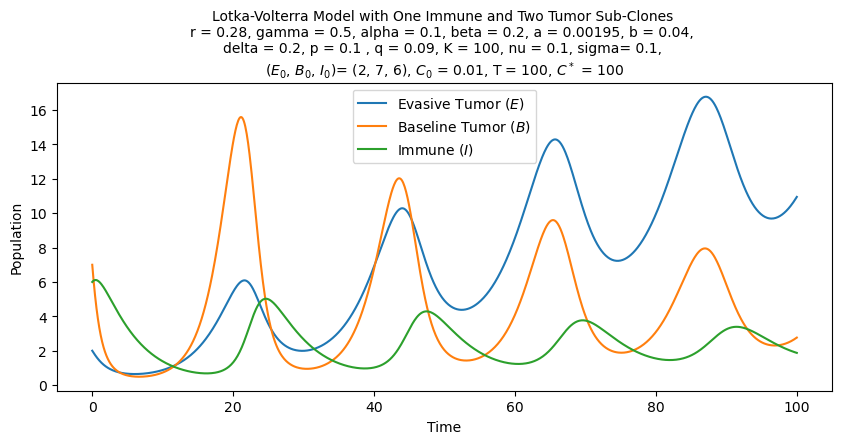

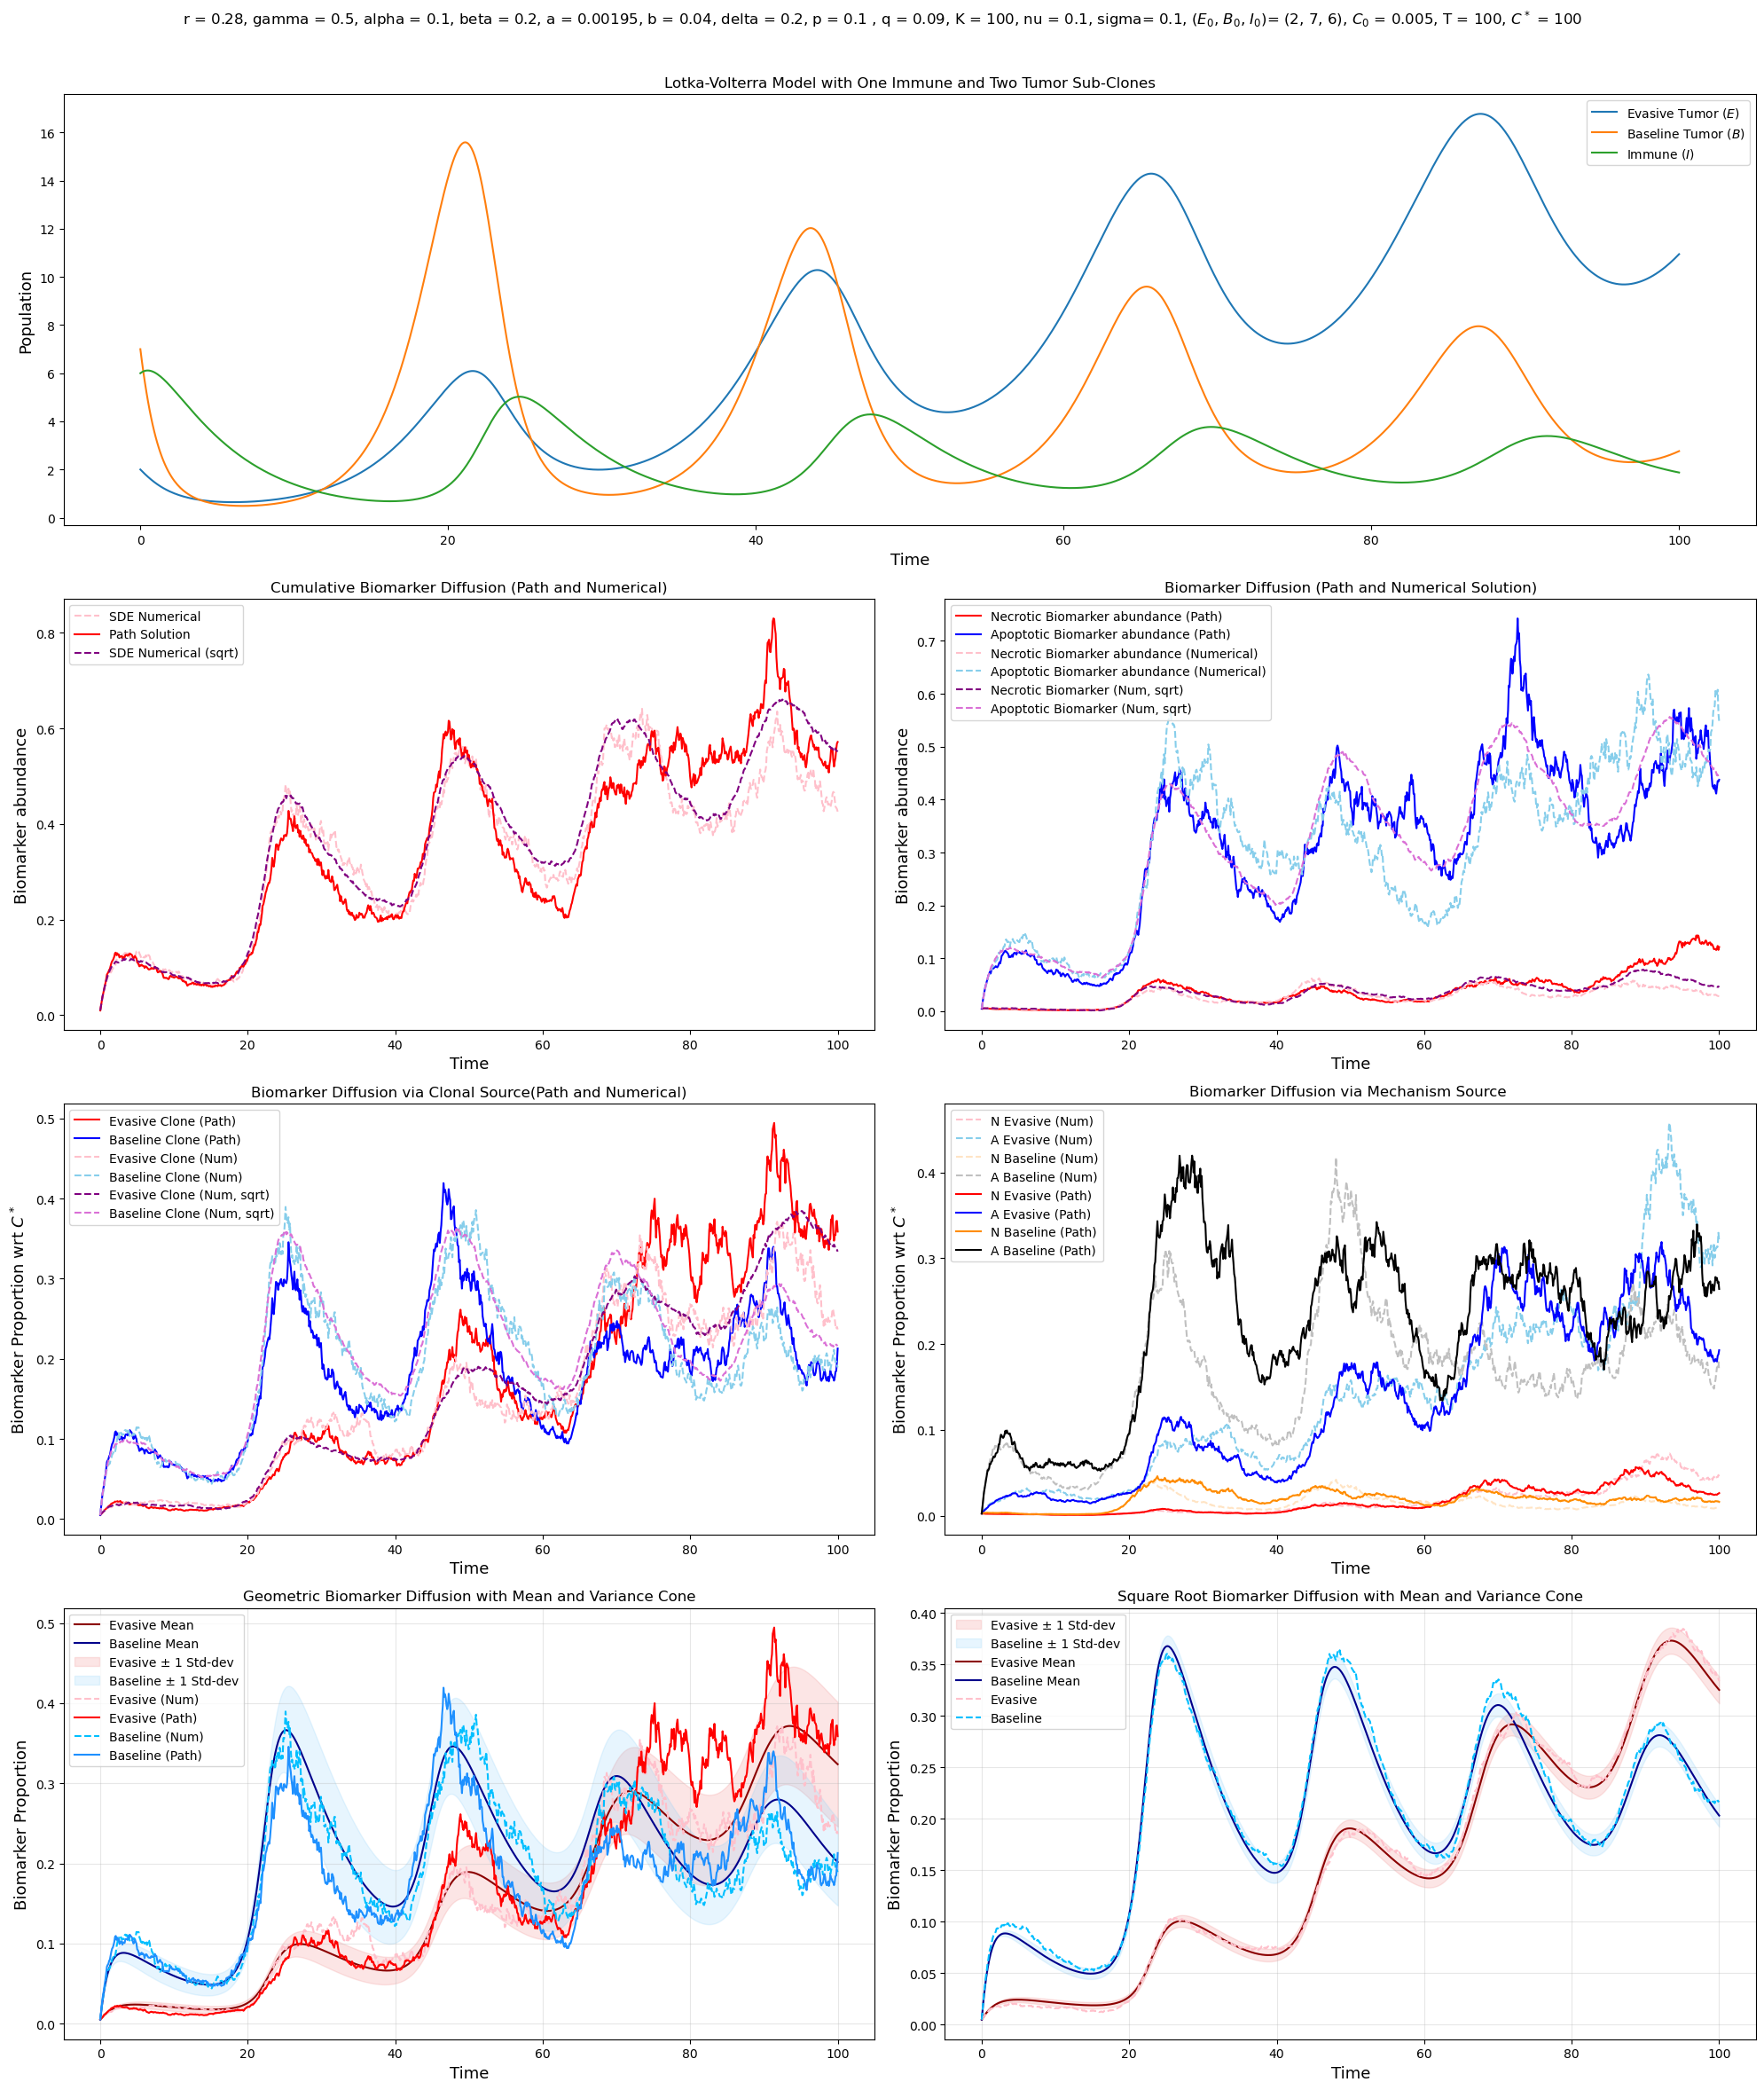

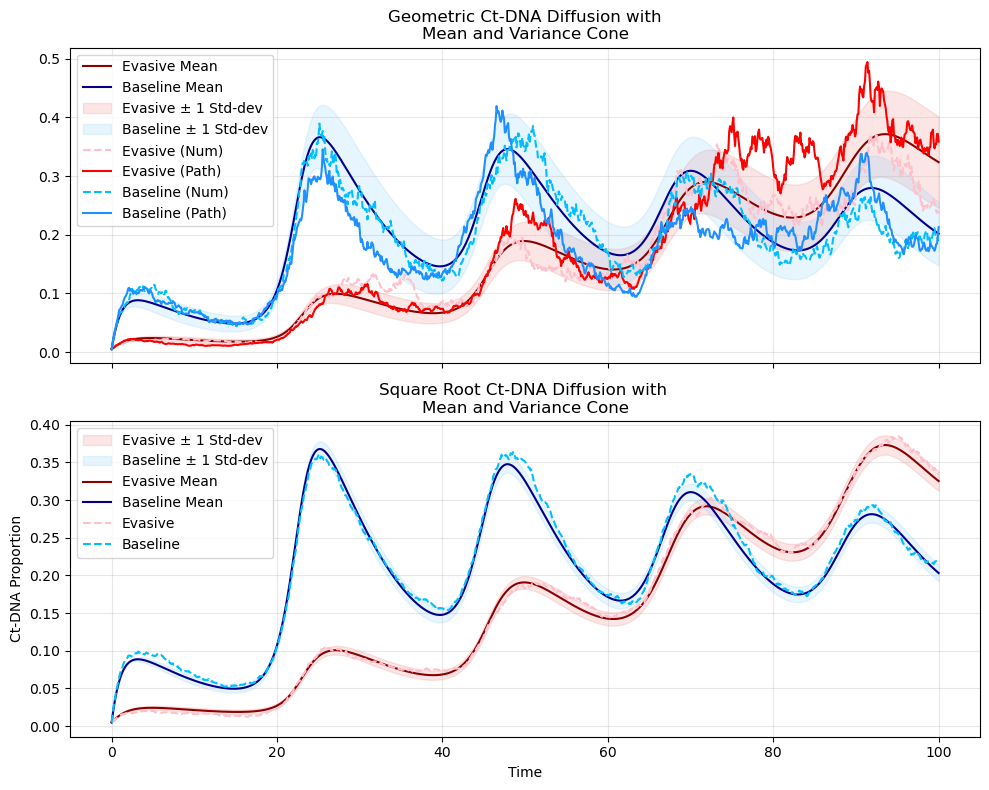

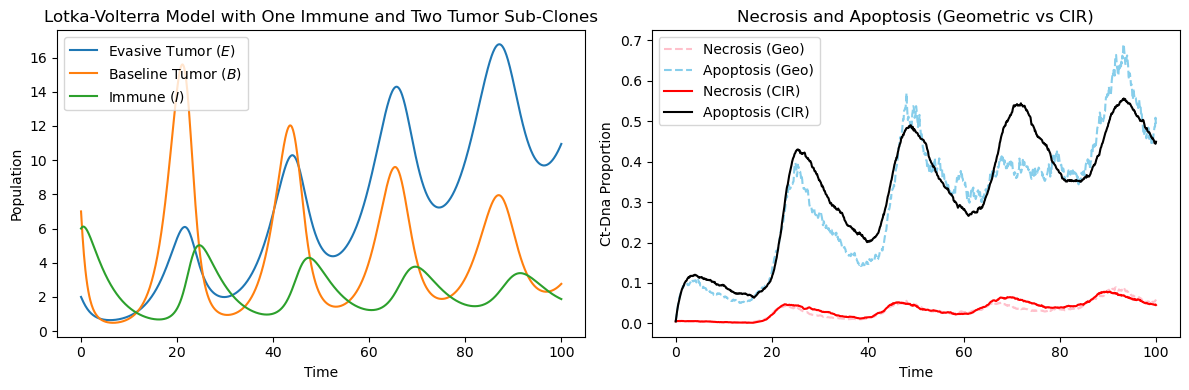

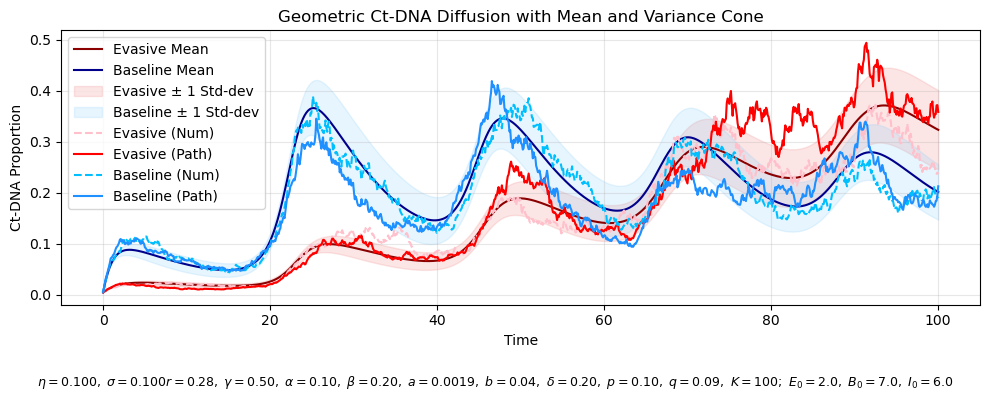

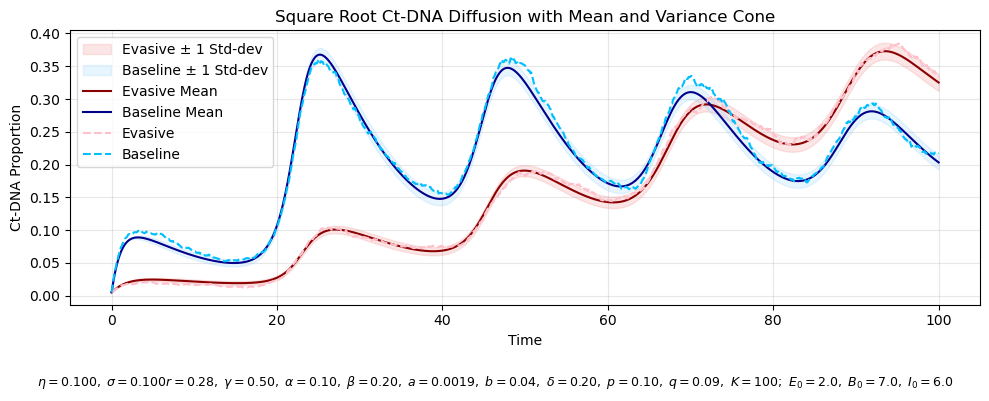

In [29]:
# Create and solve
# ODE parameters
r, gamma, alpha, beta, a, b, delta, p, q, K =[0.28, 0.5, 0.1, 0.2, 0.00195, 0.04, .2, .1, .09, 100]



# ODE Initial Conditions
R_0 = 2
S_0 = 7
I_0 = 6

# Ct-Dna Decay and Volatility
nu = 0.1
sigma = 0.1
# SDE Initial Conditions
cstar = 100

xi = sigma**2 /(2*cstar) + 1e-4  # to ensure non-negativity in SDE with sqrt
'''
Important: In order to avoid fake noise, when breaking the initial c_0 concentration into different proportions, we need to ensure that
it sums up to 1. for example, for the all compartments modelling, I assumed every thing is equally split uniformly. 25% apop eva, 
25% necro eva, and the same for baseline. 
'''
inital_proportion_a_n = .5
initial_e_b = .5
C_0 = 1

if sigma**2 > 2* nu:
    logging.info('volatile')
else:
    logging.info('not volatile')
#  Simulation Details
T = 100
steps = 1000
plot = True
model = LotkaVolterraModel(r, gamma, alpha, beta, a, b, delta, p,q, K, nu, xi, sigma, R_0, S_0, I_0, C_0 , inital_proportion_a_n ,initial_e_b,T, steps, cstar, plot)



## Equilibrium Point Analysis

In [30]:
model.ode_details()

+-----------------------------------------------------------+----------------+----------------+
| Eqpoints                                                  | Existance      | Stability      |
+===========================================================+================+================+
| (0, 0, 0)                                                 | Exists         | Unstable       |
+-----------------------------------------------------------+----------------+----------------+
| (0, 100, 0)                                               | Exists         | Unstable       |
+-----------------------------------------------------------+----------------+----------------+
| (100, 0, 0)                                               | Exists         | Unstable       |
+-----------------------------------------------------------+----------------+----------------+
| (0, 5.0, 2.375)                                           | Exists         | Unstable       |
+---------------------------------------

,Eqpoints,Existance,Stability
0,"(0, 0, 0)",Exists,Unstable
1,"(0, 100, 0)",Exists,Unstable
2,"(100, 0, 0)",Exists,Unstable
3,"(0, 5.0, 2.375)",Exists,Unstable
4,"(102.56410256410257, 0, -0.07179487179487216)",Does not exist,Does not exist
5,"(90.81735620585268, 91.82643794147326, 0)",Exists,Unstable
6,"(15.31738859022259, 4.253277306226648, 2.359203943016333)",Exists,Stable


## Mean hitting time given interior equilibrium point

**Mean hitting time Helper Code**

In [31]:
#Helper Code
def _trapz_cum(y, x):
    dx = np.diff(x)
    out = np.zeros_like(y, dtype=np.float64)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def _clustered_grid(a, b, n, power=3.0):
    t = np.linspace(0.0, 1.0, n, dtype=np.float64)
    return a + (b - a) * np.power(t, power)

def _rev_cumtrapz(y, x):
    dx = np.diff(x)
    trap = 0.5 * (y[:-1] + y[1:]) * dx
    out = np.zeros_like(y, dtype=np.float64)
    out[:-1] = np.cumsum(trap[::-1])[::-1]
    return out

def _logaddexp(a, b):
    m = np.maximum(a, b)
    return m + np.log(np.exp(a - m) + np.exp(b - m))

def _rev_cumtrapz_logexp(P, x):
    """
    logG[i] = log ∫_{x[i]}^{1} exp(P(s)) ds via backward trapz in log-space.
    """
    n = len(x)
    dx = np.diff(x)
    logG = np.full(n, -np.inf, dtype=np.float64)
    logG[-1] = -np.inf  # log(0)

    for i in range(n - 2, -1, -1):
        log_trap = np.log(0.5 * dx[i]) + _logaddexp(P[i], P[i + 1])
        logG[i] = _logaddexp(logG[i + 1], log_trap) if np.isfinite(logG[i + 1]) else log_trap
    return logG

def _safe_exp(u):
    return np.exp(np.clip(u, -745.0, 709.0))

def compute_k_and_logE_geo(
    fstar=100.0, eta=0.1, sigma=0.1,
    eps=0.01, n_x=300, n_y=6000,
    grid_power=3.0, refine_k=True
):
    A = 2.0 * fstar / (sigma**2)
    B = 2.0 * eta   / (sigma**2)
    C = 2.0 / (sigma**2)

    def phi(v):
        return np.exp(A * (1.0 - 1.0 / v)) * np.power(v, -(B + 2.0))

    def compute_R_at_x(x0):
        v = _clustered_grid(x0, 1.0, n_y, power=grid_power)

        hx = np.power(v, B) * np.exp(A * (1.0 / v - 1.0 / x0))   
        H  = _trapz_cum(hx, v)
        J  = H[-1]  # J(x0)

        I  = np.trapezoid(phi(v) * H, v) 
        R  = (C * I) / J
        return R, J  

    x_grid = np.linspace(eps, 1.0 - eps, n_x)
    R_grid = np.empty_like(x_grid)
    for i, x0 in enumerate(x_grid):
        R_grid[i], _ = compute_R_at_x(x0)

    if refine_k:
        imax = int(np.argmax(R_grid))
        x_star = x_grid[imax]
        lo = max(eps, x_star - 5*(x_grid[1]-x_grid[0]))
        hi = min(1.0 - eps, x_star + 5*(x_grid[1]-x_grid[0]))
        x_ref = np.linspace(lo, hi, 6*n_x // 50 + 20)  
        R_ref = np.empty_like(x_ref)
        for i, x0 in enumerate(x_ref):
            R_ref[i], _ = compute_R_at_x(x0)
        k = float(np.max(np.concatenate([R_grid, R_ref])))
    else:
        k = float(np.max(R_grid))

    c0_grid = x_grid.copy()
    logE = np.empty_like(c0_grid)

    tiny = 1e-300
    for i, c0 in enumerate(c0_grid):
        R_c0, J_c0 = compute_R_at_x(c0)

        diff = k - R_c0
        if diff <= 0:
            diff = tiny

        logE[i] = A * (1.0 / c0 - 1.0) + np.log(max(J_c0, tiny)) + np.log(diff)

    return c0_grid, logE, k, R_grid

def sweep_expected_hitting_times_geo(
    c0_grid: np.ndarray,
    f: float = 0.2,
    eta: float = 0.1,
    sigma: float = 0.3,
    dt: float = 1e-3,
    T_max: float = 500.0,
    n_paths: int = 1000,
    threshold: float = 1.0,
    floor: float = 1e-12,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    
    rng = np.random.default_rng(seed)
    c0_grid = np.asarray(c0_grid, dtype=np.float64)
    n_c0 = c0_grid.size
    n_steps = int(np.ceil(T_max / dt))
    sqrt_dt = np.sqrt(dt)

    C = np.broadcast_to(c0_grid, (n_paths, n_c0)).copy()
    
    tau = np.full((n_paths, n_c0), np.nan, dtype=np.float64)

    t = 0.0
    for _ in range(n_steps):
        hit = (C >= threshold) & np.isnan(tau)
        if hit.any():
            tau[hit] = t
            
        if np.isfinite(tau).all():
            break

        Z = rng.standard_normal(C.shape)
        
        drift = (f - eta * C) * dt
        diffusion = sigma * C * sqrt_dt * Z
        
        C = C + drift + diffusion
        C = np.maximum(C, floor)
        
        t += dt

    hit_mask = np.isfinite(tau)
    hit_rates = hit_mask.mean(axis=0)

    E_tau_hitonly = np.nanmean(tau, axis=0)

    taus_cens = np.where(hit_mask, tau, T_max)
    E_tau_censored = taus_cens.mean(axis=0)

    return E_tau_hitonly, E_tau_censored, hit_rates


def expected_tau_closed_form_cir(
    *,
    c0_grid,
    sigma,
    eta,
    f_star,
    x_min=1e-10,
    n_x=8000,
    grid_power=4.5,
    x_opt_min=1e-4,   
):
    
    c0_grid = np.asarray(c0_grid, dtype=np.float64)

    x = _clustered_grid(x_min, 1.0, n_x, power=grid_power)
    sig2 = float(sigma) ** 2

    p = 2.0 * (f_star - eta * x) / (sig2 * x)
    q = -2.0 / (sig2 * x)

    P = _rev_cumtrapz(p, x)

    logG = _rev_cumtrapz_logexp(P, x)

    H1 = q * _safe_exp(-P)
    J1 = _rev_cumtrapz(H1, x)

    H2 = q * _safe_exp(logG - P)
    J2 = _rev_cumtrapz(H2, x)

    kx = -J1 + J2 * _safe_exp(-logG)

    # sup over x in [x_opt_min, 1)
    i0 = int(np.searchsorted(x, x_opt_min))
    i0 = min(max(i0, 0), n_x - 2)
    ksup = float(np.max(kx[i0:-1]))
    logk = np.log(max(ksup, 1e-300))

    c0c = np.clip(c0_grid, x[0], 1.0)
    logGc = np.interp(c0c, x, logG)
    J1c = np.interp(c0c, x, J1)
    J2c = np.interp(c0c, x, J2)

    term_kG = _safe_exp(logk + logGc)

    absJ1 = np.abs(J1c)
    signJ1 = np.sign(J1c)
    term_GJ1 = signJ1 * _safe_exp(logGc + np.log(np.maximum(absJ1, 1e-300)))

    Etau = term_kG + term_GJ1 - J2c
    return Etau, {"ksup": ksup, "x_opt_min": x_opt_min}


def mc_mean_hit_time_cir_to_1(
    *,
    c0_grid,
    f,
    nu,
    sigma,
    dt=0.1,
    T_max=50.0,
    n_paths=2000,
    seed=1,
):
    
    rng = np.random.default_rng(seed)
    c0_grid = np.asarray(c0_grid, dtype=np.float64)
    n_c0 = c0_grid.size
    n_steps = int(np.ceil(T_max / dt))
    sqrt_dt = np.sqrt(dt)

    C = np.broadcast_to(c0_grid, (n_paths, n_c0)).copy()
    tau = np.full((n_paths, n_c0), np.nan, dtype=np.float64)

    t = 0.0
    for _ in range(n_steps):
        hit = (C >= 1.0) & np.isnan(tau)
        if hit.any():
            tau[hit] = t
        if np.isfinite(tau).all():
            break

        Z = rng.standard_normal(C.shape)
        Cpos = np.maximum(C, 0.0)
        C = C + (f - nu * Cpos) * dt + sigma * np.sqrt(Cpos) * sqrt_dt * Z
        C = np.maximum(C, 0.0)
        t += dt

    tau[np.isnan(tau)] = T_max
    mean_tau = tau.mean(axis=0)
    hit_frac = np.mean(tau < T_max, axis=0)
    return mean_tau, hit_frac




**Geometric SDE Mean Hitting Time**

Computed fstar = 0.128310149167513

Running Geometric integral method...
Integral done. k = 18.113155263186062

Running Geometric Monte Carlo...


INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


MC done.


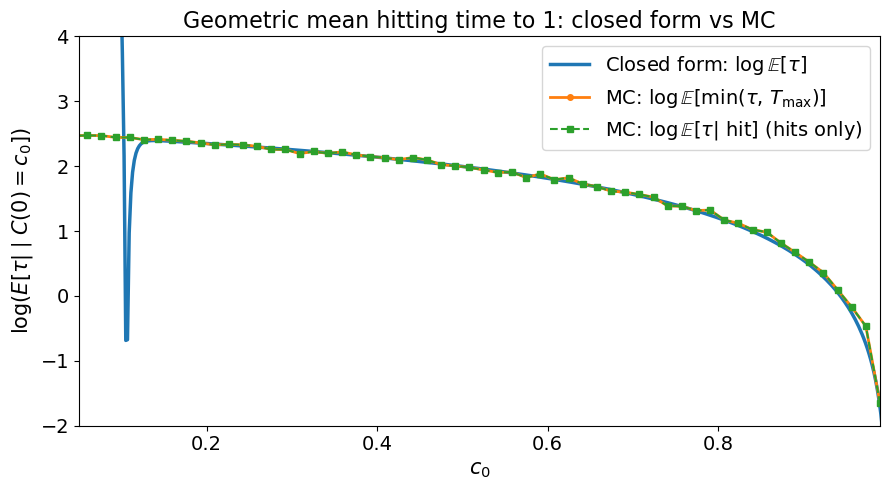


Summary:
 k = 18.1132
  MC E[tau|hit] mean = 6.9919
  MC E[min(tau,T)] mean = 6.9919


In [32]:
if __name__ == "__main__":
    
    r, gamma, alpha, beta, a, b, delta, p, q, K =[0.28, 0.5, 0.1, 0.2, 0.00195, 0.04, .2, .1, .09, 100]

    eqstate = (15.31738859022259, 4.253277306226648, 2.359203943016333)
    cstar = 50.0

    evasive_apoptosis  = lambda E, B, I: (alpha * E * I) / cstar
    evasive_necrosis   = lambda E, B, I: (r * E * ((E + p * B) / K)) / cstar
    baseline_apoptosis = lambda E, B, I: (beta * B * I) / cstar
    baseline_necrosis  = lambda E, B, I: (gamma * B * (((q * E) + B) / K)) / cstar

    fstar = (
        evasive_apoptosis(*eqstate)
        + evasive_necrosis(*eqstate)
        + baseline_apoptosis(*eqstate)
        + baseline_necrosis(*eqstate)
    )
    print("Computed fstar =", fstar)

    eta = 0.1
    sigma = 0.25

    eps_stable = 0.001
    n_x = 500         
    n_y = 8000  
    grid_power = 3.0
    refine_k = True

    eps_mc = 0.01
    n_c0_mc = 60
    c0_grid_mc = np.linspace(eps_mc, 0.99, n_c0_mc)
    dt = 1e-3
    T_max = 500.0
    n_paths = 1000
    seed = 42

    print("\nRunning Geometric integral method...")
    c0_stable, logE_stable, k, R_stable = compute_k_and_logE_geo(
        fstar=fstar,
        eta=eta,
        sigma=sigma,
        eps=eps_stable,
        n_x=n_x,
        n_y=n_y,
        grid_power=grid_power,
        refine_k=refine_k,
    )
    print("Integral done. k =", k)

    print("\nRunning Geometric Monte Carlo...")
    E_hit, E_cens, hit_rates = sweep_expected_hitting_times_geo(
        c0_grid_mc,
        f=fstar,
        eta=eta,
        sigma=sigma,
        dt=dt,
        T_max=T_max,
        n_paths=n_paths,
        seed=seed
    )
    print("MC done.")

    tiny = 1e-300
    log_mc_cens = np.log(np.maximum(E_cens, tiny))
    log_mc_hit  = np.log(np.maximum(E_hit, tiny))

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(c0_stable, logE_stable, linewidth=2.5, label=r"Closed form: $\log \mathbb{E}[\tau]$")
    ax.plot(
        c0_grid_mc, log_mc_cens, "o-", linewidth=2, markersize=4,
        label=r"MC: $\log \mathbb{E}$[min($\tau$, $T_{\max}$)]"
    )
    ax.plot(
        c0_grid_mc, log_mc_hit, "s--", linewidth=1.5, markersize=4,
        label=r"MC: $\log \mathbb{E}$[$\tau $| hit] (hits only)"
    )

    ax.set_xlabel(r"$c_0$", fontsize=15)
    ax.set_ylabel(r"$\log(E[\tau | \mid C(0)=c_0])$", fontsize=15)
    ax.set_title("Geometric mean hitting time to 1: closed form vs MC",fontsize=16)
    ax.set_xlim(0.05, 0.99)
    ax.set_ylim(-2, 4)

    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.legend(fontsize=14)

    plt.tight_layout()
    plt.show()



    print("\nSummary:")
    print(f" k = {k:.6g}")
    finite_hit = np.isfinite(E_hit)
    if np.any(finite_hit):
        print(f"  MC E[tau|hit] mean = {np.mean(E_hit[finite_hit]):.4f}")
    print(f"  MC E[min(tau,T)] mean = {np.mean(E_cens):.4f}")



**CIR SDE Mean Hitting Time**

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


Closed-form: ksup (restricted to x >= 0.0001) = 32.3458
MC hit fraction range: [1.0000, 1.0000]


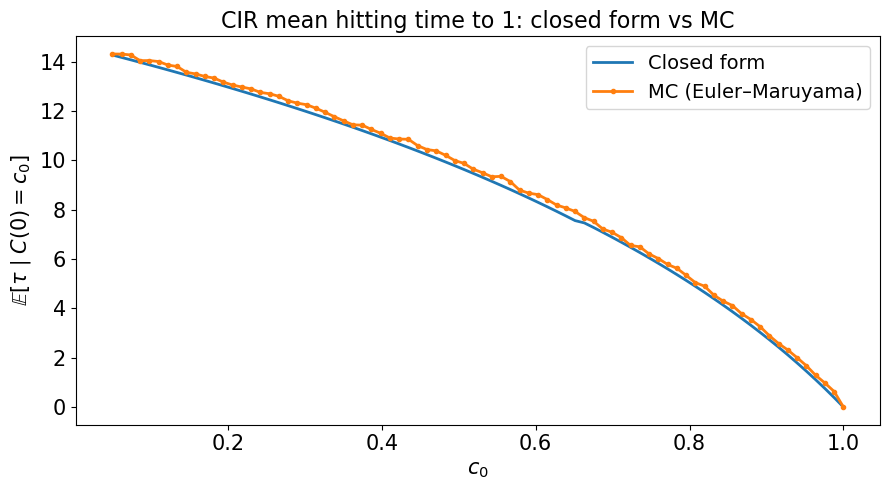

In [33]:
if __name__ == "__main__":
    cstar = 50
    fhat_orig  = 0.128310149167513
    nu    = 0.1
    sigma_orig = 0.25
    sigma = sigma / np.sqrt(cstar)  # Scale volatility by 1/sqrt(c0)
    fhat = fhat_orig + (sigma**2 / 2.0   ) + 1e-4 
    c0 = np.linspace(0.05, 1.0, 80)

    cf, diag = expected_tau_closed_form_cir(
        c0_grid=c0,
        sigma=sigma,
        eta=nu,
        f_star=fhat,
        x_opt_min=1e-4,   
    )

    mc, hit_frac = mc_mean_hit_time_cir_to_1(
        c0_grid=c0,
        f=fhat,
        nu=nu,
        sigma=sigma,
        dt=0.1,
        T_max=50.0,
        n_paths=2000,
        seed=1,
    )

    print(f"Closed-form: ksup (restricted to x >= {diag['x_opt_min']}) = {diag['ksup']:.6g}")
    print(f"MC hit fraction range: [{hit_frac.min():.4f}, {hit_frac.max():.4f}]")

    plt.figure(figsize=(9, 5))
    plt.plot(c0, cf, label="Closed form ", linewidth=2)
    plt.plot(c0, mc, "o-", label="MC (Euler–Maruyama)",linewidth=2, markersize=3)
    plt.xlabel(r"$c_0$", fontsize=15)
    plt.ylabel(r"$\mathbb{E}[\tau \mid C(0)=c_0]$", fontsize=15 )
    plt.title("CIR mean hitting time to 1: closed form vs MC", fontsize=16)
    plt.tick_params(axis="both", which="major", labelsize=15)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()
